# Proyek Akhir: Menyelesaikan Permasalahan Human Resources - Jaya Jaya Maju

- Nama: Putera Nami Shiddieqy
- Email: puteranami1150@gmail.com
- Id Dicoding: puteranami

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
load_dotenv()

True

### Menyiapkan data yang akan diguankan

In [2]:
df = pd.read_csv("data/employee_data.csv", encoding='windows-1252')
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [3]:
URL = os.getenv("URL")
engine = create_engine(URL)
try:
    # Menggunakan if_exists='replace' agar tidak error jika tabel sudah ada
    df.to_sql('employees', engine, if_exists='replace', index=False)
    print("Data successfully uploaded to Supabase!")
except Exception as e:
    print(f"Note: Database upload skipped or failed: {e}")

Data successfully uploaded to Supabase!


## Data Understanding

In [4]:
print("Shape data:", df.shape)
print("\nMissing values per kolom:")
missing = df.isnull().sum()
print(missing[missing > 0])
print("\nDistribusi Target (Attrition):")
print(df['Attrition'].value_counts(dropna=False))
print("\nInfo Data:")
df.info()
print("\nStatistik Deskriptif:")
print(df.describe())

Shape data: (1470, 35)

Missing values per kolom:
Attrition    412
dtype: int64

Distribusi Target (Attrition):
Attrition
0.0    879
NaN    412
1.0    179
Name: count, dtype: int64

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-

## Data Preparation / Preprocessing

In [5]:
# Drop baris dengan missing Attrition
df_clean = df.dropna(subset=['Attrition']).copy()
df_clean['Attrition'] = df_clean['Attrition'].astype(int)

# Drop kolom yang tidak relevan
drop_cols = ['EmployeeId', 'EmployeeCount', 'Over18', 'StandardHours']
df_clean = df_clean.drop(columns=drop_cols)
print(f"Kolom setelah di-drop: {df_clean.shape[1]} kolom tersisa.")

# Pisahkan fitur dan target
X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']

# Encode binary categorical columns (Gender & OverTime)
label_encoders = {}
for col in ['Gender', 'OverTime']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# One-hot encode multi-class categorical columns
ohe_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
X_encoded = pd.get_dummies(X, columns=ohe_cols, drop_first=True)

# Train-test split (80:20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling untuk fitur numerik
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()
numerical_cols.remove('Gender')
numerical_cols.remove('OverTime')

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# SMOTE oversampling untuk menangani imbalance data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribusi kelas sebelum SMOTE:", y_train.value_counts().to_dict())
print("Distribusi kelas setelah SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

Kolom setelah di-drop: 31 kolom tersisa.
Distribusi kelas sebelum SMOTE: {0: 703, 1: 143}
Distribusi kelas setelah SMOTE: {0: 703, 1: 703}


## Modeling

In [6]:
# Gunakan Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)

print("Melatih model Gradient Boosting...")
gb_model.fit(X_train_res, y_train_res)
print("Training selesai!")

# Simpan model dan preprocessor ke folder model/
import joblib
import os
os.makedirs('model', exist_ok=True)
joblib.dump(gb_model, 'model/model.joblib')

preprocessor_data = {
    'label_encoders': label_encoders,
    'ohe_cols': ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'],
    'scaler': scaler,
    'num_cols_to_scale': numerical_cols,
    'feature_columns': X_encoded.columns.tolist(),
    'drop_cols': ['EmployeeId', 'EmployeeCount', 'Over18', 'StandardHours'],
    'binary_cols': ['Gender', 'OverTime'],
    'threshold': 0.30,
    'model_name': 'GradientBoosting'
}
joblib.dump(preprocessor_data, 'model/preprocessor.joblib')
print("Model dan preprocessor berhasil disimpan ke folder model/!")


Melatih model Gradient Boosting...
Training selesai!
Model dan preprocessor berhasil disimpan ke folder model/!


## Evaluation

--- Classification Report (Threshold = 0.30) ---
              precision    recall  f1-score   support

No Attrition       0.88      0.89      0.88       176
   Attrition       0.43      0.42      0.42        36

    accuracy                           0.81       212
   macro avg       0.65      0.65      0.65       212
weighted avg       0.80      0.81      0.81       212

ROC-AUC Score: 0.8045


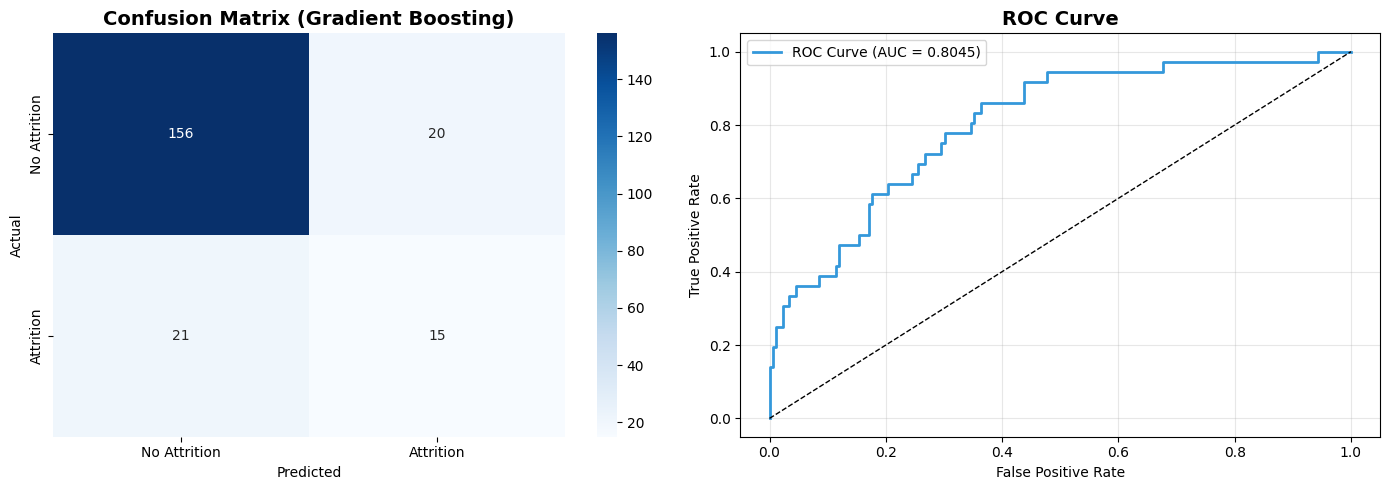


--- Top 10 Fitur Paling Berpengaruh ---
                         Feature  Importance
                StockOptionLevel    0.196601
                        JobLevel    0.068876
         EnvironmentSatisfaction    0.057668
                  JobInvolvement    0.052250
               TotalWorkingYears    0.047007
                 JobSatisfaction    0.036753
                             Age    0.036116
              NumCompaniesWorked    0.032763
                DistanceFromHome    0.029536
BusinessTravel_Travel_Frequently    0.029112


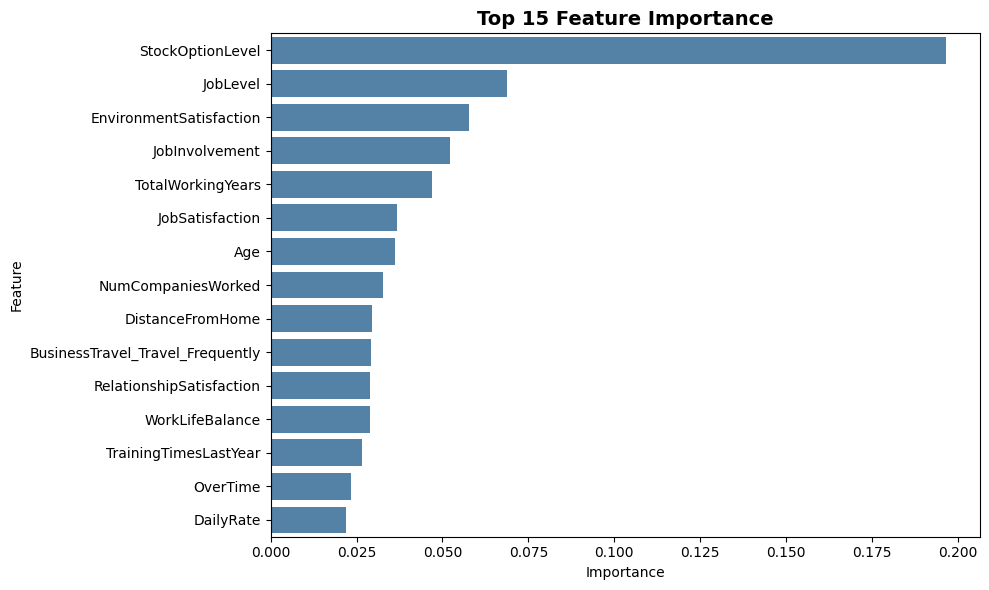

In [9]:
# Prediksi probabilitas dan kelas dengan threshold optimal 0.30
y_pred_proba = gb_model.predict_proba(X_test)[:, 1]
best_threshold = 0.30
y_pred_final = (y_pred_proba >= best_threshold).astype(int)

print("--- Classification Report (Threshold = 0.30) ---")
print(classification_report(y_test, y_pred_final, target_names=['No Attrition', 'Attrition']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Visualisasi Confusion Matrix dan ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'], ax=axes[0])
axes[0].set_title('Confusion Matrix (Gradient Boosting)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#3498db', linewidth=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n--- Top 10 Fitur Paling Berpengaruh ---")
print(feature_importance.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature', color='steelblue', ax=ax)
ax.set_title('Top 15 Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()